In [1]:
import numpy as np
import pandas as pd

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/meirnizri/covid19-dataset/Covid Data.csv


In [8]:
file_path = "/kaggle/input/datasets/meirnizri/covid19-dataset/Covid Data.csv"
df = pd.read_csv(file_path)
df.shape

(1048575, 21)

In [7]:
df.head()

,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,DATE_DIED,INTUBED,PNEUMONIA,AGE,PREGNANT,DIABETES,...,ASTHMA,INMSUPR,HIPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,CLASIFFICATION_FINAL,ICU
0,2,1,1,1,03/05/2020,97,1,65,2,2,...,2,2,1,2,2,2,2,2,3,97
1,2,1,2,1,03/06/2020,97,1,72,97,2,...,2,2,1,2,2,1,1,2,5,97
2,2,1,2,2,09/06/2020,1,2,55,97,1,...,2,2,2,2,2,2,2,2,3,2
3,2,1,1,1,12/06/2020,97,2,53,2,2,...,2,2,2,2,2,2,2,2,7,97
4,2,1,2,1,21/06/2020,97,2,68,97,1,...,2,2,1,2,2,2,2,2,3,97


In [11]:
clean_df = df.copy()

Diagnosis

In [14]:
# DIAGNOSIS 1: Basic Structure & Overview
print("Shape:", df.shape)
print("\nColumn Names:\n", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nFirst 5 Rows:")
df.head()

Shape: (1048575, 21)

Column Names:
 ['USMER', 'MEDICAL_UNIT', 'SEX', 'PATIENT_TYPE', 'DATE_DIED', 'INTUBED', 'PNEUMONIA', 'AGE', 'PREGNANT', 'DIABETES', 'COPD', 'ASTHMA', 'INMSUPR', 'HIPERTENSION', 'OTHER_DISEASE', 'CARDIOVASCULAR', 'OBESITY', 'RENAL_CHRONIC', 'TOBACCO', 'CLASIFFICATION_FINAL', 'ICU']

Data Types:
 USMER                    int64
MEDICAL_UNIT             int64
SEX                      int64
PATIENT_TYPE             int64
DATE_DIED               object
INTUBED                  int64
PNEUMONIA                int64
AGE                      int64
PREGNANT                 int64
DIABETES                 int64
COPD                     int64
ASTHMA                   int64
INMSUPR                  int64
HIPERTENSION             int64
OTHER_DISEASE            int64
CARDIOVASCULAR           int64
OBESITY                  int64
RENAL_CHRONIC            int64
TOBACCO                  int64
CLASIFFICATION_FINAL     int64
ICU                      int64
dtype: object

First 5 Rows:


,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,DATE_DIED,INTUBED,PNEUMONIA,AGE,PREGNANT,DIABETES,...,ASTHMA,INMSUPR,HIPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,CLASIFFICATION_FINAL,ICU
0,2,1,1,1,03/05/2020,97,1,65,2,2,...,2,2,1,2,2,2,2,2,3,97
1,2,1,2,1,03/06/2020,97,1,72,97,2,...,2,2,1,2,2,1,1,2,5,97
2,2,1,2,2,09/06/2020,1,2,55,97,1,...,2,2,2,2,2,2,2,2,3,2
3,2,1,1,1,12/06/2020,97,2,53,2,2,...,2,2,2,2,2,2,2,2,7,97
4,2,1,2,1,21/06/2020,97,2,68,97,1,...,2,2,1,2,2,2,2,2,3,97


                    97    98     99   total    pct
ICU             848544     0   7488  856032  81.64
INTUBED         848544     0   7325  855869  81.62
PREGNANT        523511  3754      0  527265  50.28
PNEUMONIA            0     0  16003   16003   1.53
OTHER_DISEASE        0  5045      0    5045   0.48
INMSUPR              0  3404      0    3404   0.32
DIABETES             0  3338      0    3338   0.32
TOBACCO              0  3220      0    3220   0.31
HIPERTENSION         0  3104      0    3104   0.30
CARDIOVASCULAR       0  3076      0    3076   0.29
OBESITY              0  3032      0    3032   0.29
RENAL_CHRONIC        0  3006      0    3006   0.29
COPD                 0  3003      0    3003   0.29
ASTHMA               0  2979      0    2979   0.28
PATIENT_TYPE         0     0      0       0   0.00
SEX                  0     0      0       0   0.00


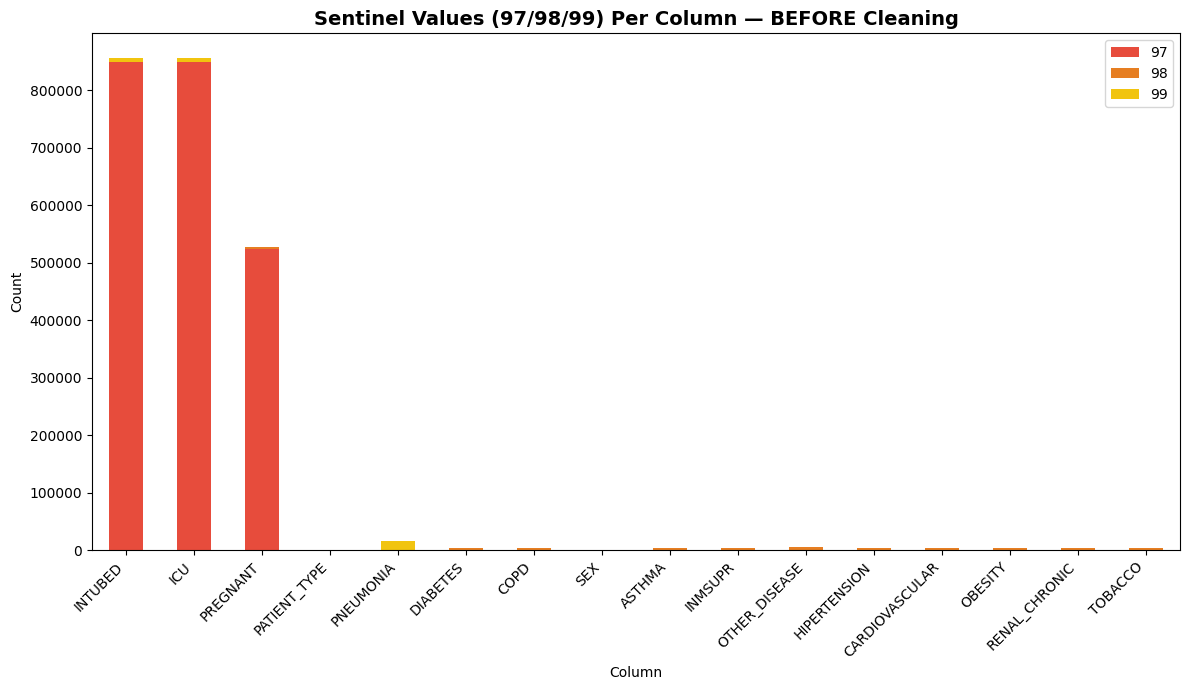

In [15]:
# DIAGNOSIS 1 VISUALIZATION: Sentinel value heatmap
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sentinel_values = [97, 98, 99]

sentinel_cols = [col for col in df.columns if col not in ['AGE', 'DATE_DIED', 
                  'MEDICAL_UNIT', 'CLASIFFICATION_FINAL', 'USMER']]

sentinel_counts = pd.DataFrame({
    col: [(df[col] == v).sum() for v in sentinel_values]
    for col in sentinel_cols
}, index=['97', '98', '99']).T

sentinel_counts['total'] = sentinel_counts.sum(axis=1)
sentinel_counts['pct'] = (sentinel_counts['total'] / len(df) * 100).round(2)

print(sentinel_counts.sort_values('total', ascending=False))

# Plot
fig, ax = plt.subplots(figsize=(12, 7))
sentinel_counts[['97','98','99']].sort_values('97', ascending=False).plot(
    kind='bar', stacked=True, ax=ax,
    color=['#e74c3c','#e67e22','#f1c40f']
)
ax.set_title('Sentinel Values (97/98/99) Per Column — BEFORE Cleaning', fontsize=14, fontweight='bold')
ax.set_ylabel('Count')
ax.set_xlabel('Column')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [16]:
# FULL DATASET DIAGNOSIS
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 50)
print("1. SHAPE")
print("=" * 50)
print(df.shape)

print("\n" + "=" * 50)
print("2. MISSING VALUES")
print("=" * 50)
print(df.isnull().sum())

print("\n" + "=" * 50)
print("3. BASIC STATS")
print("=" * 50)
print(df.describe())

print("\n" + "=" * 50)
print("4. UNIQUE VALUES PER COLUMN")
print("=" * 50)
print(df.nunique())

print("\n" + "=" * 50)
print("5. VALUE COUNTS OF KEY COLUMNS")
print("=" * 50)
for col in ['SEX', 'PATIENT_TYPE', 'CLASIFFICATION_FINAL', 'ICU', 'INTUBED']:
    print(f"\n{col}:\n", df[col].value_counts(dropna=False))

1. SHAPE
(1048575, 21)

2. MISSING VALUES
USMER                   0
MEDICAL_UNIT            0
SEX                     0
PATIENT_TYPE            0
DATE_DIED               0
INTUBED                 0
PNEUMONIA               0
AGE                     0
PREGNANT                0
DIABETES                0
COPD                    0
ASTHMA                  0
INMSUPR                 0
HIPERTENSION            0
OTHER_DISEASE           0
CARDIOVASCULAR          0
OBESITY                 0
RENAL_CHRONIC           0
TOBACCO                 0
CLASIFFICATION_FINAL    0
ICU                     0
dtype: int64

3. BASIC STATS
              USMER  MEDICAL_UNIT           SEX  PATIENT_TYPE       INTUBED  \
count  1.048575e+06  1.048575e+06  1.048575e+06  1.048575e+06  1.048575e+06   
mean   1.632194e+00  8.980565e+00  1.499259e+00  1.190765e+00  7.952288e+01   
std    4.822084e-01  3.723278e+00  4.999997e-01  3.929041e-01  3.686889e+01   
min    1.000000e+00  1.000000e+00  1.000000e+00  1.000000e+00  1.00

cleaning.......1

In [17]:
# DIAGNOSIS: DATE_DIED column
print(df['DATE_DIED'].value_counts().head(10))
print("\nSample unique values:", df['DATE_DIED'].unique()[:10])
print("\nDtype:", df['DATE_DIED'].dtype)

DATE_DIED
9999-99-99    971633
06/07/2020      1000
07/07/2020       996
13/07/2020       990
16/06/2020       979
16/07/2020       938
14/07/2020       935
17/06/2020       926
29/06/2020       925
08/06/2020       923
Name: count, dtype: int64

Sample unique values: ['03/05/2020' '03/06/2020' '09/06/2020' '12/06/2020' '21/06/2020'
 '9999-99-99' '26/02/2020' '05/04/2020' '08/05/2020' '20/05/2020']

Dtype: object


9999-99-99 appears 971,633 times → this means alive/survivor, not a real date
Real dates are in DD/MM/YYYY format (e.g. 03/05/2020)
Dtype is object (plain string) — Python doesn't know it's a date yet


Why it's a problem:

Can't do any time analysis (trends, monthly deaths) on a string
9999-99-99 will crash any datetime calculation
No way to tell who died vs survived without parsing this first

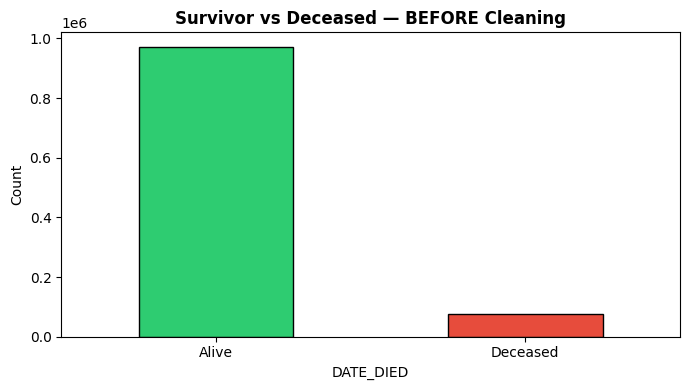

In [19]:
died_raw = df['DATE_DIED'].apply(lambda x: 'Alive' if x == '9999-99-99' else 'Deceased')
died_raw.value_counts().plot(kind='bar', color=['#2ecc71','#e74c3c'], edgecolor='black', figsize=(7,4))
plt.title('Survivor vs Deceased — BEFORE Cleaning', fontweight='bold')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [20]:
# CLEANING STEP 1: Create DIED binary column & parse date
df['DIED'] = df['DATE_DIED'].apply(lambda x: 0 if x == '9999-99-99' else 1)

df['DATE_DIED'] = pd.to_datetime(
    df['DATE_DIED'].replace('9999-99-99', np.nan),
    format='%d/%m/%Y',
    errors='coerce'
)

print("✅ Done!")
print(df['DIED'].value_counts())
print("\nDate range:", df['DATE_DIED'].min(), "→", df['DATE_DIED'].max())

✅ Done!
DIED
0    971633
1     76942
Name: count, dtype: int64

Date range: 2020-01-02 00:00:00 → 2021-05-02 00:00:00


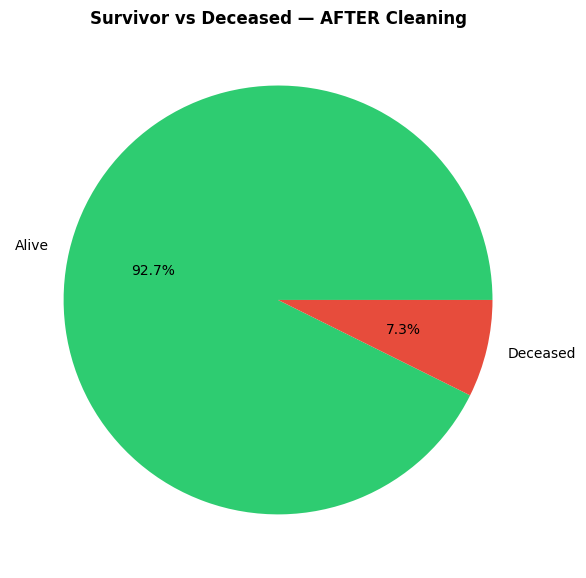

In [21]:
# AFTER: Clean pie chart
df['DIED'].value_counts().rename({0:'Alive', 1:'Deceased'}).plot(
    kind='pie', autopct='%1.1f%%',
    colors=['#2ecc71','#e74c3c'],
    figsize=(6,6), ylabel=''
)
plt.title('Survivor vs Deceased — AFTER Cleaning', fontweight='bold')
plt.tight_layout()
plt.show()

✅ Cleaning Step 1 — Summary
Problem: DATE_DIED stored survivors as "9999-99-99" (a fake date), making it impossible to distinguish who died vs survived, and unusable for time analysis.
Fix: Created a new DIED column (1 = Deceased, 0 = Alive) and converted DATE_DIED to proper datetime.
Result: Out of ~1M patients, 92.7% survived and 7.3% died from COVID-19.

cleaning........2

In [22]:
# DIAGNOSIS: Binary columns still encoded as 1/2
binary_cols = ['SEX', 'INTUBED', 'PNEUMONIA', 'PREGNANT', 'DIABETES', 
               'COPD', 'ASTHMA', 'INMSUPR', 'HIPERTENSION', 'OTHER_DISEASE',
               'CARDIOVASCULAR', 'OBESITY', 'RENAL_CHRONIC', 'TOBACCO', 'ICU']

for col in binary_cols:
    print(f"{col}: {df[col].unique()}")

SEX: [1 2]
INTUBED: [97  1  2 99]
PNEUMONIA: [ 1  2 99]
PREGNANT: [ 2 97 98  1]
DIABETES: [ 2  1 98]
COPD: [ 2  1 98]
ASTHMA: [ 2  1 98]
INMSUPR: [ 2  1 98]
HIPERTENSION: [ 1  2 98]
OTHER_DISEASE: [ 2  1 98]
CARDIOVASCULAR: [ 2  1 98]
OBESITY: [ 2  1 98]
RENAL_CHRONIC: [ 2  1 98]
TOBACCO: [ 2  1 98]
ICU: [97  2  1 99]


What we see:

All binary columns use 1/2 instead of 1/0 (Yes/No)
INTUBED and ICU still have 97 and 99 sentinels — not cleaned yet
PNEUMONIA still has 99, PREGNANT still has 97/98

Why it's a problem:

2 means "No" but mathematically looks like twice as much as 1
Any mean, correlation, or chart will be misleading
Standard ML models expect 0/1 for binary features

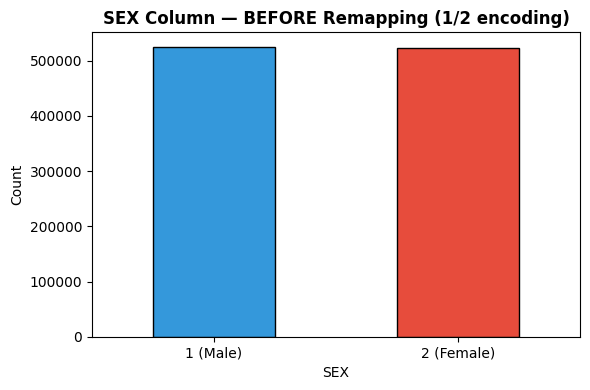

In [23]:
# BEFORE: Show encoding of SEX as example
df['SEX'].value_counts().plot(kind='bar', color=['#3498db','#e74c3c'], 
                               edgecolor='black', figsize=(6,4))
plt.title('SEX Column — BEFORE Remapping (1/2 encoding)', fontweight='bold')
plt.xticks([0,1], ['1 (Male)', '2 (Female)'], rotation=0)
plt.ylabel('Count')
plt.tight_layout()
plt.show()

Solution

In [24]:
# Remap 1/2 → 1/0 (1=Yes, 2=No → 1=Yes, 0=No)
remap_cols = ['PNEUMONIA', 'PREGNANT', 'DIABETES', 'COPD', 'ASTHMA', 
              'INMSUPR', 'HIPERTENSION', 'OTHER_DISEASE', 'CARDIOVASCULAR', 
              'OBESITY', 'RENAL_CHRONIC', 'TOBACCO', 'INTUBED', 'ICU']

for col in remap_cols:
    df[col] = df[col].replace({1: 1, 2: 0, 97: np.nan, 98: np.nan, 99: np.nan})

# SEX: 1=Male, 2=Female → 1=Male, 0=Female
df['SEX'] = df['SEX'].replace({1: 1, 2: 0})

print("✅ Done!")
for col in binary_cols:
    print(f"{col}: {df[col].unique()}")

✅ Done!
SEX: [1 0]
INTUBED: [nan  1.  0.]
PNEUMONIA: [ 1.  0. nan]
PREGNANT: [ 0. nan  1.]
DIABETES: [ 0.  1. nan]
COPD: [ 0.  1. nan]
ASTHMA: [ 0.  1. nan]
INMSUPR: [ 0.  1. nan]
HIPERTENSION: [ 1.  0. nan]
OTHER_DISEASE: [ 0.  1. nan]
CARDIOVASCULAR: [ 0.  1. nan]
OBESITY: [ 0.  1. nan]
RENAL_CHRONIC: [ 0.  1. nan]
TOBACCO: [ 0.  1. nan]
ICU: [nan  0.  1.]


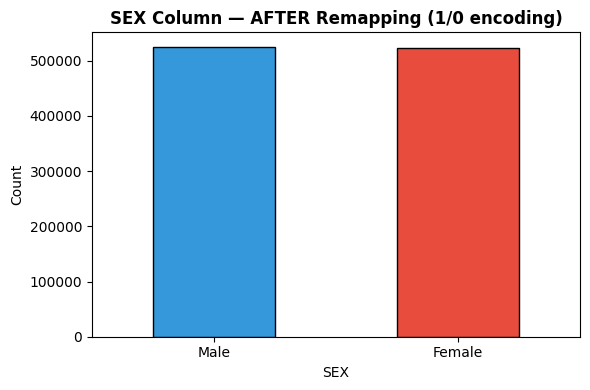

In [25]:
# AFTER: SEX distribution with clean labels
df['SEX'].value_counts().rename({1:'Male', 0:'Female'}).plot(
    kind='bar', color=['#3498db','#e74c3c'], edgecolor='black', figsize=(6,4))
plt.title('SEX Column — AFTER Remapping (1/0 encoding)', fontweight='bold')
plt.xticks(rotation=0)
plt.ylabel('Count')
plt.tight_layout()
plt.show()

Cleaning Step 2 — Summary
Problem: Binary columns used 1/2 encoding instead of 1/0, and INTUBED, ICU, PNEUMONIA, PREGNANT still had leftover sentinel values (97/98/99).
Fix: Remapped all binary columns to 1/0 (Yes/No) and replaced remaining sentinels with NaN.
Result: All binary columns now clean with only 0, 1, and NaN values — ready for accurate analysis and modeling.

cleaning.......3

In [31]:
# DIAGNOSIS: CLASIFFICATION_FINAL values
print(df['CLASIFFICATION_FINAL'].value_counts().sort_index())
print("\nUnique values:", sorted(df['CLASIFFICATION_FINAL'].unique()))

CLASIFFICATION_FINAL
1      8601
2      1851
3    381527
4      3122
5     26091
6    128133
7    499250
Name: count, dtype: int64

Unique values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]


What we see:

Values 1, 2, 3 = COVID confirmed (~392,000 patients)
Values 4, 5, 6, 7 = Not confirmed/negative (~656,000 patients)
Stored as raw integers — no clear Yes/No signal

Why it's a problem:

Can't easily filter or analyze COVID positive vs negative patients
Integer values imply a ranking or order that doesn't exist
Every analysis needs complex filtering instead of a simple binary flag

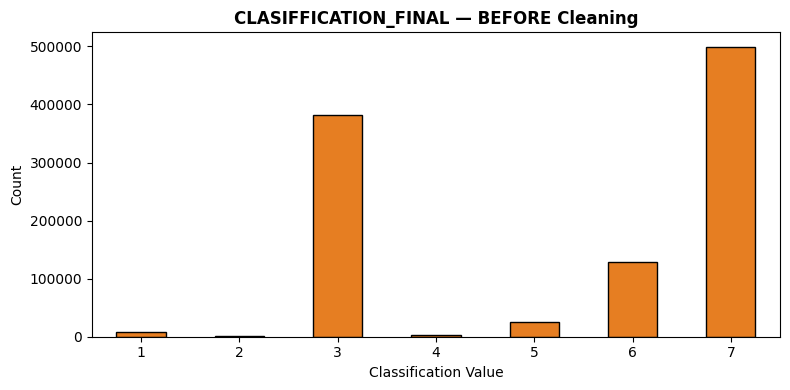

In [32]:
# BEFORE: Raw classification values
df['CLASIFFICATION_FINAL'].value_counts().sort_index().plot(
    kind='bar', color='#e67e22', edgecolor='black', figsize=(8, 4))
plt.title('CLASIFFICATION_FINAL — BEFORE Cleaning', fontweight='bold')
plt.xlabel('Classification Value')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Solution

In [33]:
# 1-3 = COVID confirmed, 4-7 = not confirmed
df['COVID_POSITIVE'] = df['CLASIFFICATION_FINAL'].apply(
    lambda x: 1 if x in [1, 2, 3] else 0)

print("✅ Done!")
print(df['COVID_POSITIVE'].value_counts())
print(f"\nCOVID Positive: {df['COVID_POSITIVE'].mean()*100:.2f}%")

✅ Done!
COVID_POSITIVE
0    656596
1    391979
Name: count, dtype: int64

COVID Positive: 37.38%


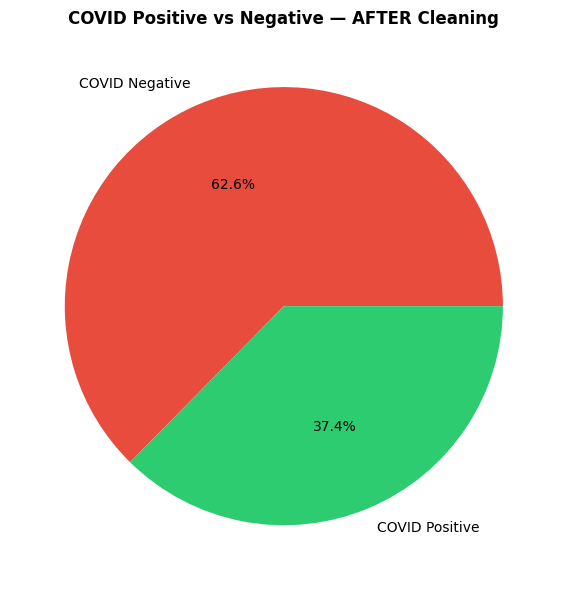

In [34]:
# AFTER: Clean COVID positive vs negative
df['COVID_POSITIVE'].value_counts().rename({1:'COVID Positive', 0:'COVID Negative'}).plot(
    kind='pie', autopct='%1.1f%%',
    colors=['#e74c3c','#2ecc71'],
    figsize=(6,6), ylabel='')
plt.title('COVID Positive vs Negative — AFTER Cleaning', fontweight='bold')
plt.tight_layout()
plt.show()

Cleaning Step 5 — Summary
Problem: CLASIFFICATION_FINAL stored COVID status as integers 1–7 with no clear meaning — hard to filter or analyze.
Fix: Created a new COVID_POSITIVE binary column where 1–3 = Positive, 4–7 = Negative.
Result: 37.4% of patients tested COVID Positive, 62.6% were negative — now instantly filterable for targeted analysis.

cleaning........4

In [35]:
# DIAGNOSIS: Check PATIENT_TYPE and DATE_DIED
print("PATIENT_TYPE values:", df['PATIENT_TYPE'].value_counts())
print("\nDATE_DIED nulls:", df['DATE_DIED'].isnull().sum())
print("\nDATED_DIED sample (non-null):", df['DATE_DIED'].dropna().head(5))
print("\nUSMER values:", df['USMER'].value_counts())
print("\nMEDICAL_UNIT values:", df['MEDICAL_UNIT'].value_counts())

PATIENT_TYPE values: PATIENT_TYPE
1    848544
2    200031
Name: count, dtype: int64

DATE_DIED nulls: 971633

DATED_DIED sample (non-null): 0   2020-05-03
1   2020-06-03
2   2020-06-09
3   2020-06-12
4   2020-06-21
Name: DATE_DIED, dtype: datetime64[ns]

USMER values: USMER
2    662903
1    385672
Name: count, dtype: int64

MEDICAL_UNIT values: MEDICAL_UNIT
12    602995
4     314405
6      40584
9      38116
3      19175
8      10399
10      7873
5       7244
11      5577
13       996
7        891
2        169
1        151
Name: count, dtype: int64


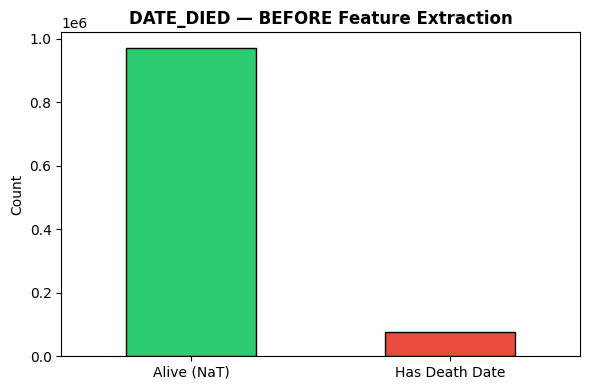

In [36]:
# BEFORE: Show raw DATE_DIED nulls vs non-nulls
pd.Series({'Alive (NaT)': df['DATE_DIED'].isnull().sum(),
           'Has Death Date': df['DATE_DIED'].notnull().sum()}).plot(
    kind='bar', color=['#2ecc71','#e74c3c'], edgecolor='black', figsize=(6,4))
plt.title('DATE_DIED — BEFORE Feature Extraction', fontweight='bold')
plt.xticks(rotation=0)
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [40]:
# CORRECTED: Extract DEATH_MONTH as period (YYYY-MM)
df['DEATH_MONTH'] = df['DATE_DIED'].dt.to_period('M')

print("✅ Done!")
print(df['DEATH_MONTH'].value_counts().sort_index())

✅ Done!
DEATH_MONTH
2020-01      368
2020-02      437
2020-03      552
2020-04     6926
2020-05    21314
2020-06    25278
2020-07    20457
2020-08     1134
2020-09       91
2020-10       27
2020-11       18
2020-12       23
2021-01       31
2021-02       35
2021-03       32
2021-04      170
2021-05       49
Freq: M, Name: count, dtype: int64


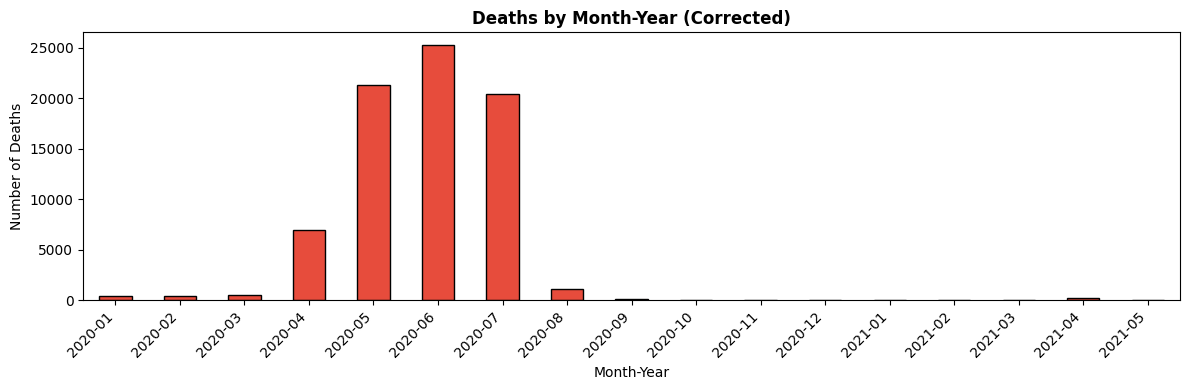

In [41]:
death_by_month = df['DEATH_MONTH'].value_counts().sort_index()

plt.figure(figsize=(12, 4))
death_by_month.plot(kind='bar', color='#e74c3c', edgecolor='black')
plt.title('Deaths by Month-Year (Corrected)', fontweight='bold')
plt.xlabel('Month-Year')
plt.ylabel('Number of Deaths')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()